In [89]:
from utils import * 
from files.pdb import PDBFile
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass, asdict
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re
import orjson
import ast  

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/ppi' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.

MMSEQS_DIR = '../data/genes/mmseqs'
MMSEQS_DATABASE_DIR = '../data/genes/mmseqs/db'
MMSEQS_TMP_DIR = '../data/tmp'

In [25]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]

In [26]:
# Interested in looking at potential protein-protein interactions, particularly potential interactions with the ATPase as a possible hint at function. 

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['alphafold_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{int(row.cluster_id)}_1mer', axis=1)
genes_df = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].copy()

FASTAFile.from_df(genes_df).write('../data/genes/level_1_conserved_clusters.faa')

In [27]:
def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}
 

In [28]:
names = list() # Store the names of the AlphaFold jobs to access the output directories.

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)


for genome_id, df in genes_df.groupby('genome_id'):

    pairs = list(itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2))
    pairs += [(entry, entry) for entry in df.reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 
    for pair in pairs:

        alphafold_ids = [ pair[0]['alphafold_id'],  pair[1]['alphafold_id']]
        gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
        seqs = [pair[0]['seq'], pair[1]['seq']]

        name = '-'.join(alphafold_ids)
        names.append(name)
        
        msas = get_msas_unpaired(gene_ids)
        file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=10, version=2)

        for gene_id, alphafold_id, seq in zip(gene_ids, alphafold_ids, seqs):
            file.add_seq(seq, paired_msa="", unpaired_msa=msas[gene_id], description=alphafold_id)

        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

# https://app.gitbook.com/o/-LzcB3BNVSNh_20MBLKi/s/-M-S5z_vnCqDzDHcfsmi/protein-folding

# for name in tqdm(names, desc='Copying AlphaFold outputs.'):
#     if not os.path.exists(f' ../data/genes/alphafold/af_output/{name}')
#         subprocess.run(f'scp -r philippar@biotite.berkeley.edu:/home/philippar/af_output/{name} ../data/genes/alphafold/af_output/', shell=True, check=True)

output_dirs = [os.path.join(ALPHAFOLD_OUTPUT_DIR, name) for name in names]
outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"


In [ ]:

def get_residue(idx, token_chain_ids:np.ndarray):
    '''

    :param idx: The zero-indexed contact location relative to the token_chain_ids array. 
    :param token_chain_ids: The token_chain_ids array from the AlphaFold output. 
    :returns: A two-tuple containing (1) the chain ID and (2) zero-indexed residue number relative to the start of the chain. 
    '''
    chain_start_idxs = dict(zip(*np.unique(token_chain_ids, return_index=True))) # This is a dictionary mapping the chain IDs to their start indices.
    chain_id = token_chain_ids[idx] # Get the chain that the specified index belongs to. 
    return (chain_id, idx - chain_start_idxs[chain_id])


def get_contacts(contact_probs_df:np.ndarray, min_contact_prob=0.5):
    '''Use the contact_probs in the AlphaFold output to locate potential inter-chain residue contacts.
    Because the contact_probs matrix is symmetric, there will be duplicate entries. 
    
    :param contact_probs_df: A square DataFrame containing the contact_probs for a given structure. 
    :param min_contact_prob: The minimum contact_prob to say whether or not two residues are likely to be in contact. 
    :returns:
    '''
    token_chain_ids = contact_probs_df.index.values
    mask = (contact_probs_df.values > min_contact_prob) # Require a minimum contact probability. 
    mask = mask & (np.expand_dims(token_chain_ids, axis=1) != np.expand_dims(token_chain_ids, axis=0))  # Don't include intra-chain contacts. 
    # print(f'get_contacts: {mask.sum().sum()} inter-chain residues predicted to be in contact.')
    assert (mask.ravel().sum() % 2) == 0, f'get_contacts: The number of contacts should be divisible by 2 if the matrix is symmetric.'

    if mask.ravel().sum() == 0:
        return [], dict()

    probs = contact_probs_df.values[mask].ravel()
    probs = {'contact_prob_min':probs.min(), 'contact_prob_min':probs.min(), 'contact_prob_mean':probs.mean(), 'contact_probs':probs.tolist()}
    return list(zip(*np.where(mask))), probs # Gets the contact indices as a list of two-tuples (i1, j1), (12, j2), ...


if not os.path.exists('analysis-1-ppi-contacts.csv'):
    contacts_df = list()
    for output in tqdm(outputs, desc='Collecting protein-protein interaction data.'):
        contact_probs = output.get_contact_probs(mean_pool=False, best_model=False)

        for model, contact_probs_df in contact_probs.items():
            idxs, row = get_contacts(contact_probs_df)
            row['name'] = output.name
            row['model'] = model
            row['num_contacts'] = len(idxs)
            contacts_df.append(row)
            
    contacts_df = pd.DataFrame(contacts_df)
    contacts_df.to_csv('analysis-1-ppi-contacts.csv')
else:
    contacts_df = pd.read_csv('analysis-1-ppi-contacts.csv')

contacts_df['genome_id'] = contacts_df['name'].apply(get_genome_id)
contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
contacts_df['num_genomes_with_contact'] = contacts_df.cluster_ids.map(contacts_df.groupby('cluster_ids').apply(lambda df : df.dropna().genome_id.nunique()))
contacts_df['max_num_genomes_with_contact'] = contacts_df.cluster_ids.map(contacts_df.groupby('cluster_ids').apply(lambda df : df.genome_id.nunique()))
contacts_df['max_num_successful_dimers'] = contacts_df.groupby('cluster_ids').transform('size')

filters = dict()
# filters['contact_not_in_all_genomes'] = contacts_df.num_genomes_with_contact < contacts_df.max_num_genomes_with_contact
filters['contact_not_in_most_genomes'] =  (contacts_df.max_num_genomes_with_contact - contacts_df.num_genomes_with_contact) > 2
# filters['fewer_than_3_contacting_residues'] = contacts_df.num_contacts < 3

contacts_df = apply_filters(filters, contacts_df)
conserved_contacts = contacts_df.cluster_ids.unique()

apply_filters: 3820 entries removed by contact_not_in_most_genomes.


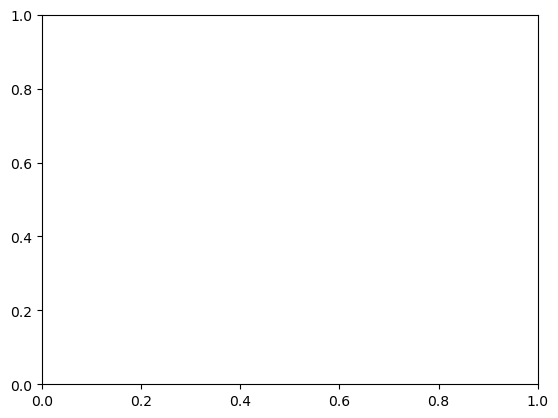

In [ ]:
fig, ax = plt.subplots()

figure_df = contacts_df.copy()


In [ ]:
contacts_df = contacts_df[contacts_df.num_contacts > 0].copy()
contacts_df = contacts_df[contacts_df.num_genomes_with_contact > 5].copy()

In [65]:
contacts_df.cluster_ids.value_counts()

cluster_ids
cluster_1, cluster_3    102
cluster_4, cluster_5    100
cluster_6, cluster_6    100
cluster_0, cluster_7     97
cluster_1, cluster_1     78
cluster_8, cluster_8     76
cluster_0, cluster_0     65
cluster_5, cluster_5     61
cluster_4, cluster_4     60
cluster_2, cluster_6     35
Name: count, dtype: int64

In [30]:
# if not os.path.exists('analysis-1-ppi_data.json'):
    
#     outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]

#     data = list()
#     for output in outputs:
#         contact_probs_df = output.get_contact_probs(models=[output.best_model])
#         paes_df =  output.get_paes(models=[output.best_model])
#         chain_ids = ['A', 'B']

#         idxs, idxs_shifted = get_interface_idxs(contact_probs_df, chain_ids=chain_ids, shift=True)
#         idxs = [idxs[chain_ids[0]], idxs[chain_ids[1]]]

#         data_ = {'name':output.name}
#         data_['iptm'] = np.mean(list(output.get_iptms().values()))
#         data_['idxs'] = idxs
#         data_['idxs_shifted'] = [idxs_shifted[chain_ids[0]], idxs_shifted[chain_ids[1]]]
#         data_['num_contacts'] = len(idxs[0])
#         data_['pae'] = [paes_df.iloc[i, j] for i, j in zip(*idxs)]
#         data_['contact_probs'] = [contact_probs_df.iloc[i, j] for i, j in zip(*idxs)]
#         data.append(data_)

#     with open('analysis-1-ppi_data.json', 'wb') as f:
#         f.write(orjson.dumps(data, default=default))

# else:
#     with open('analysis-1-ppi_data.json', 'r') as f:
#         data = json.load(f)

# data = [data_ for data_ in data if (data_['num_contacts'] > 0)]
# print(f'Loaded data for {len(data)} AlphaFold co-folds with predicted contacts.')


In [31]:
# Jack said that looking at the ipTM is not super informative; there could be a valid protein-protein interaction, but low ipTM due to disordered or low-
# confidence regions. Instead, it would be worth looking at the PAE for residues on different monomers. Any error < 10 A could be worth considering as a potential contact. 

# What would be a good potential statistic for evaluating the likelihood of a protein-protein contact? Want to evaluate both (1) predicted distance and (2) PAE. 
# There is also an output called contact_probs, which is based on a seperate output head in the model (i.e. not the pLDDT or PAE head). This is discussed in the 
# supplement of Jumper et. al. 2021. 

# TODO: Take some notes on this, I don't know if I completely understand. 
# Why isn't PAE symmetric? Asymmetry can arise due to differences in the stability of the selected reference frame. 
# The PAE asks "Asuming this residue is correctly located, how wrong is the other one likely to be?"

In [32]:
ppis = list()
for path in output_dirs:
    cluster_ids = sorted(re.findall(r'cluster_\d+', path))
    assert len(cluster_ids) == 2, f'Only expected 2 gene clusters per file, but got {len(cluster_ids)}.'
    ppis.append('-'.join(cluster_ids))

ppis, counts = np.unique(ppis, return_counts=True)
for ppi, count in zip(ppis, counts):
    print(ppi, count)

# Would be useful to look at the confidence of the residue positions at the interface, and also whether or not the cluster_1-cluster_3 interactions affect the multimerization. 

cluster_0-cluster_0 11
cluster_0-cluster_1 11
cluster_0-cluster_2 11
cluster_0-cluster_3 11
cluster_0-cluster_4 10
cluster_0-cluster_5 10
cluster_0-cluster_6 10
cluster_0-cluster_7 10
cluster_0-cluster_8 9
cluster_1-cluster_1 11
cluster_1-cluster_2 11
cluster_1-cluster_3 11
cluster_1-cluster_4 10
cluster_1-cluster_5 10
cluster_1-cluster_6 10
cluster_1-cluster_7 10
cluster_1-cluster_8 9
cluster_2-cluster_2 11
cluster_2-cluster_3 11
cluster_2-cluster_4 10
cluster_2-cluster_5 10
cluster_2-cluster_6 10
cluster_2-cluster_7 10
cluster_2-cluster_8 9
cluster_3-cluster_3 11
cluster_3-cluster_4 10
cluster_3-cluster_5 10
cluster_3-cluster_6 10
cluster_3-cluster_7 10
cluster_3-cluster_8 9
cluster_4-cluster_4 10
cluster_4-cluster_5 10
cluster_4-cluster_6 9
cluster_4-cluster_7 9
cluster_4-cluster_8 8
cluster_5-cluster_5 10
cluster_5-cluster_6 9
cluster_5-cluster_7 9
cluster_5-cluster_8 8
cluster_6-cluster_6 10
cluster_6-cluster_7 9
cluster_6-cluster_8 8
cluster_7-cluster_7 10
cluster_7-cluster_8 8
c

In [33]:
# names = list()
# ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
# ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

# for genome_id, df in genes_df[genes_df.cluster_id.isin([1, 3])].groupby('genome_id'):

#     for pair in itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2):
#         name = pair[0]['alphafold_id'].replace('1mer', '6mer') + '-' + pair[1]['alphafold_id'].replace('1mer', '6mer') + '-mg_atp'
#         names.append(name)

#         gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
#         seqs = [pair[0]['seq'], pair[1]['seq']]

#         msas = dict()
#         msas['unpaired'] = get_msas_unpaired(gene_ids)

#         file = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=1)

#         for gene_id, seq in zip(gene_ids, seqs):
#             file.add_seq(seq, paired_msa=msas['paired'][gene_id], unpaired_msa=msas['unpaired'][gene_id], n=6)
#         file.add_atp(n=6)
#         file.add_mg(n=6)

#         file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))



In [34]:
# It seems as though the cluster_1-cluster_3 contact is only predicted highly with the cluster_3 monomer. But is this a failing of AlphaFold?
# Do the contacting residues differ between the monomer predictions and the multimer predictions (i.e. does cluster_3 multimerizing block 
# the preferred interface for cluster_1 and cluster_3)?

In [35]:
# def get_msas_paired(gene_ids:list, dir_path:str=MMSEQS_DIR):
#     '''Construct paired MSAs using the specified gene IDs as queries. This is done by:
#         (1) Loading the unpaired MSA for each query gene ID. 
#         (2) Filtering each unpaired MSA to include only genes from genomes which are represented in both, i.e. contain identified homologs of each query sequence. 
#         (3) Sorting the MSAs alphabetically by gene ID (ensuring the query is still the first entry) so that rows correspond.
        
#     :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
#     :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
#         sequence. 
#     '''
#     assert len(set([get_genome_id(gene_id) for gene_id in gene_ids])) == 1, 'get_msas_paired: Expected all genes to be from the same genome.'

#     paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
#     msas = {gene_id:FASTAFile.from_file(path).to_df().reset_index(names='gene_id') for gene_id, path in paths.items()}
#     msas = {gene_id:df.assign(genome_id=df.gene_id.apply(get_genome_id)) for gene_id, df in msas.items()}

#     genome_ids = None
#     for _, df in msas.items(): # Get all genome IDs which have a representative for all chains. 
#         genome_ids = df.genome_id.unique() if (genome_ids is None) else np.intersect1d(genome_ids, df.genome_id.unique())
    
#     if len(genome_ids) < 2:
#         # If there are two few genome IDs, the paired MSA will just contain the genes from the query genome (but do not want it to throw an error). 
#         print('get_msas_paired: Too few paired sequences for a proper paired MSA.')

#     sort = lambda df : pd.concat([df.iloc[:1], df.iloc[1:].sort_values('gene_id')]) # Sort a DataFrame by genome ID, while holding the query row fixed.
#     msas = {gene_id:sort(df[df.genome_id.isin(genome_ids)].copy()) for gene_id, df in msas.items()}
    
#     return {gene_id:str(FASTAFile.from_df(df.set_index('gene_id'))) for gene_id, df in msas.items()}
